In [21]:
import numpy as np

s = np.load('../data/10k/X_spectra_10k.npy')#, mmap_mode='r')
B = np.load('../data/10k/Y_B_field_10k.npy')#, mmap_mode='r')

N_spettri, N_punti = s.shape[0], s.shape[1]

#### derivata

In [22]:
f = np.arange(2500, 3250)
x_axis = range(2500, 3250)

ds_dx = np.zeros_like(s)
d2s_dx2 = np.zeros_like(s)

for i in range(N_spettri):
    # normalizzo gli spettri
    s[i] = s[i] / np.max(np.abs(s[i]))
    ds_dx[i] = np.gradient(s[i], x_axis)
    d2s_dx2[i] = np.gradient(ds_dx[i], x_axis)
    #for j in range(N_punti//2, N_punti):
        #ds_dx[i][j] = -ds_dx[i][j]
        #d2s_dx2[i][j] = -d2s_dx2[i][j]

#### inversione post-metà

In [23]:
import matplotlib.pyplot as plt

k=10

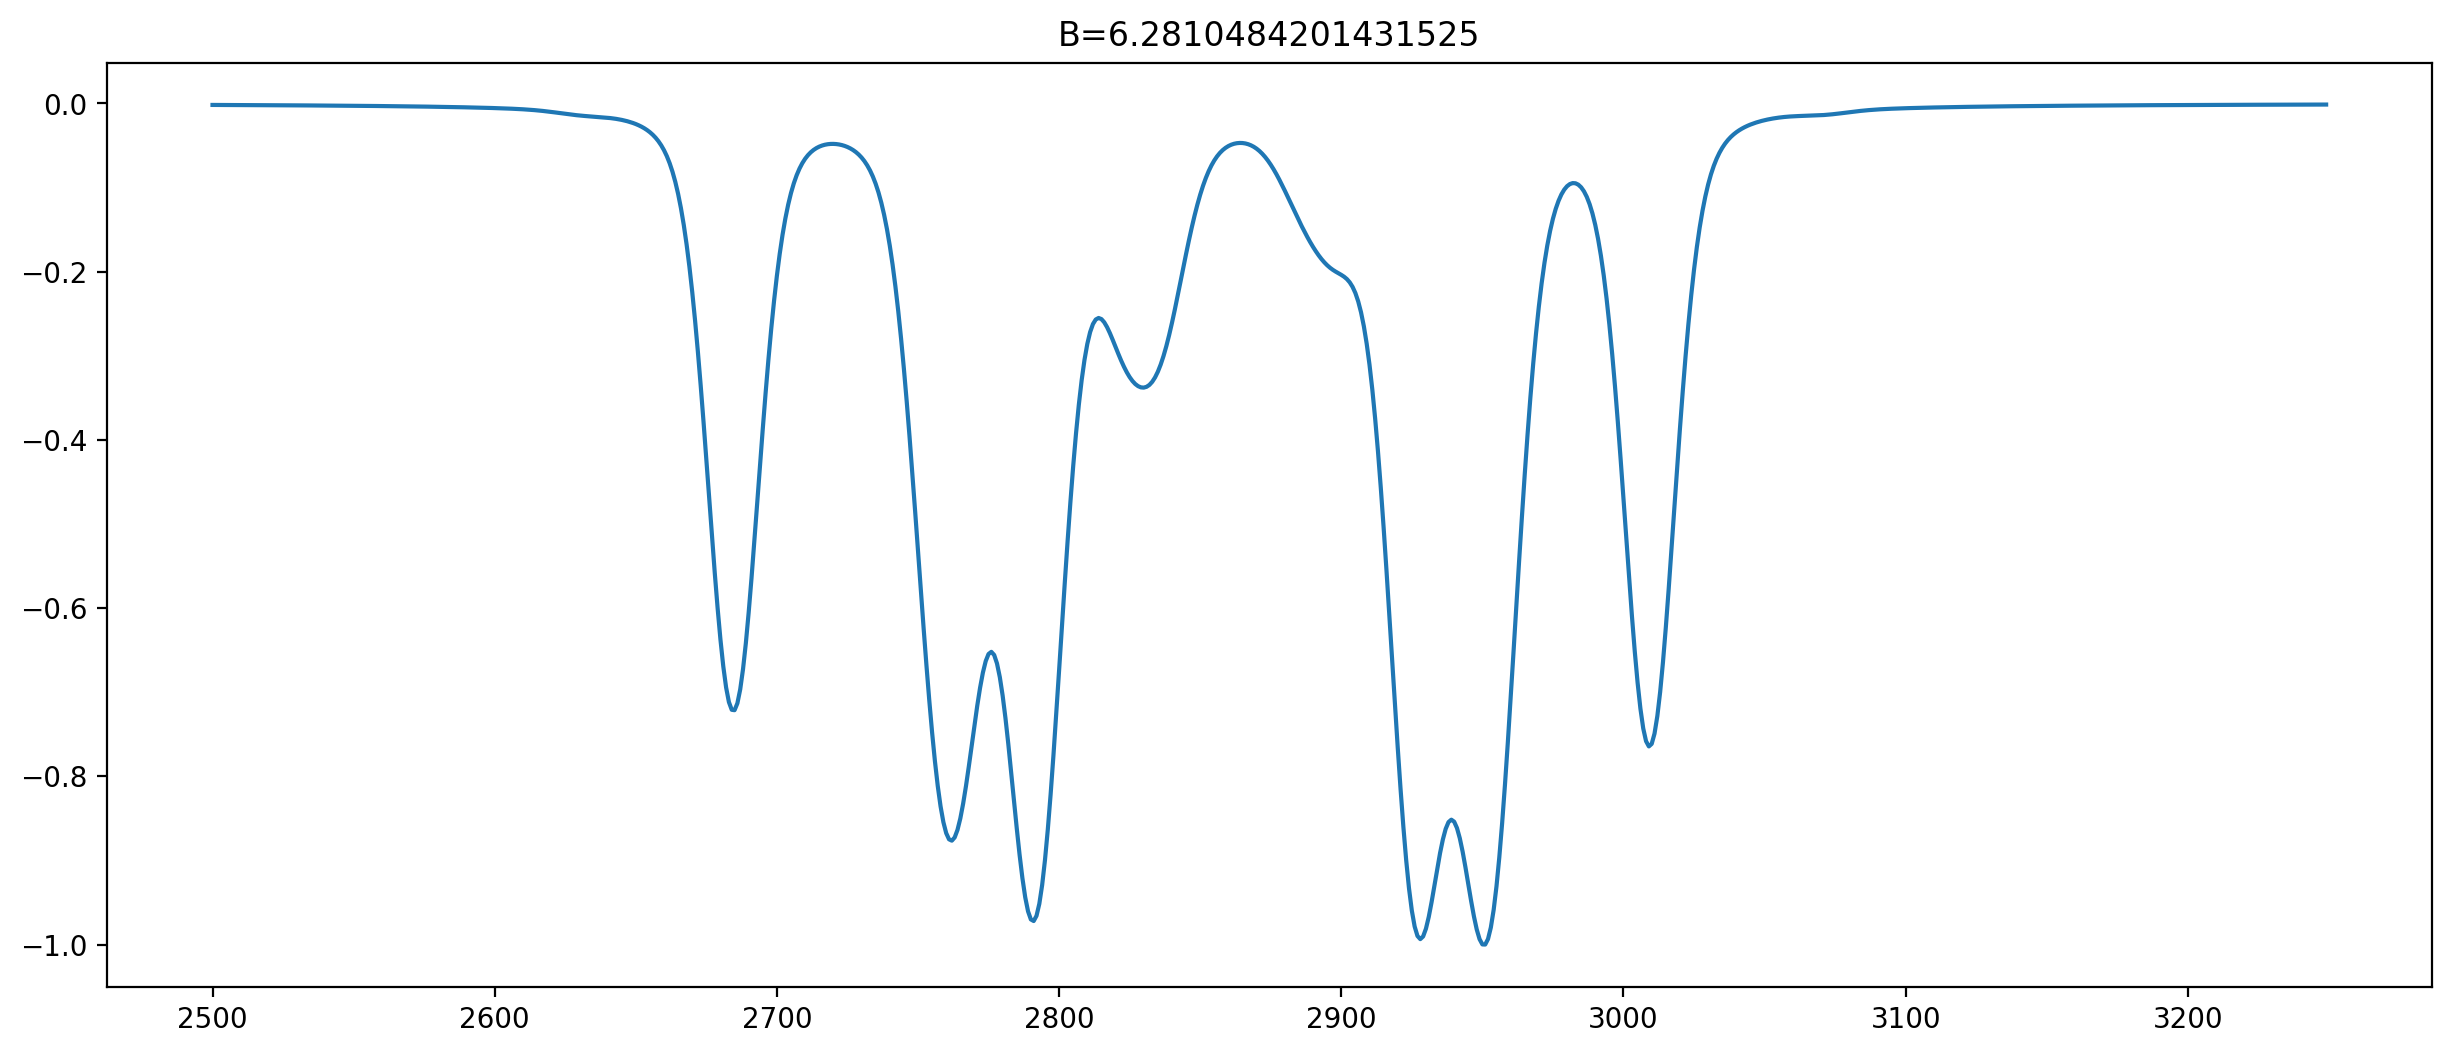

In [24]:
plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, s[k])
plt.title(f"B={B[k]}")
plt.show()

### cerco i picchi nella derivata seconda

In [25]:
from scipy.signal import find_peaks

def trova_picchi_scipy(frequenze, spettro, soglia=0.005):
    """
    Trova i picchi (massimi) in uno spettro usando scipy.
    frequenze: asse x (es. array da 750 elementi)
    spettro: asse y (es. array da 750 elementi)
    soglia: valore sotto il quale considerare valido il picco
    """
    # find_peaks cerca i massimi, quindi invertiamo lo spettro
    # La soglia diventa positiva per la ricerca dei massimi
    indici_picchi, info = find_peaks(
        spettro, 
        height=soglia,
        #prominence=0.000001,  # Prominenza minima del picco
        width=1 # Utile perché è la stima del gamma della lorentziana
    )
    
    # Estraiamo le posizioni in frequenza
    posizioni = frequenze[indici_picchi]
    
    return posizioni, info

In [26]:
# Liste per salvare i risultati di tutti gli spettri
num_picchi_totale = np.zeros(N_spettri, dtype=int)
posizioni_totali = []
info_totale = [] 

for i in range(N_spettri):
    spettro_corrente = d2s_dx2[i]
    pos, info = trova_picchi_scipy(f, spettro_corrente, soglia=0.005)
    
    num_picchi_totale[i] = len(pos)
    posizioni_totali.append(pos)
    info_totale.append(info)

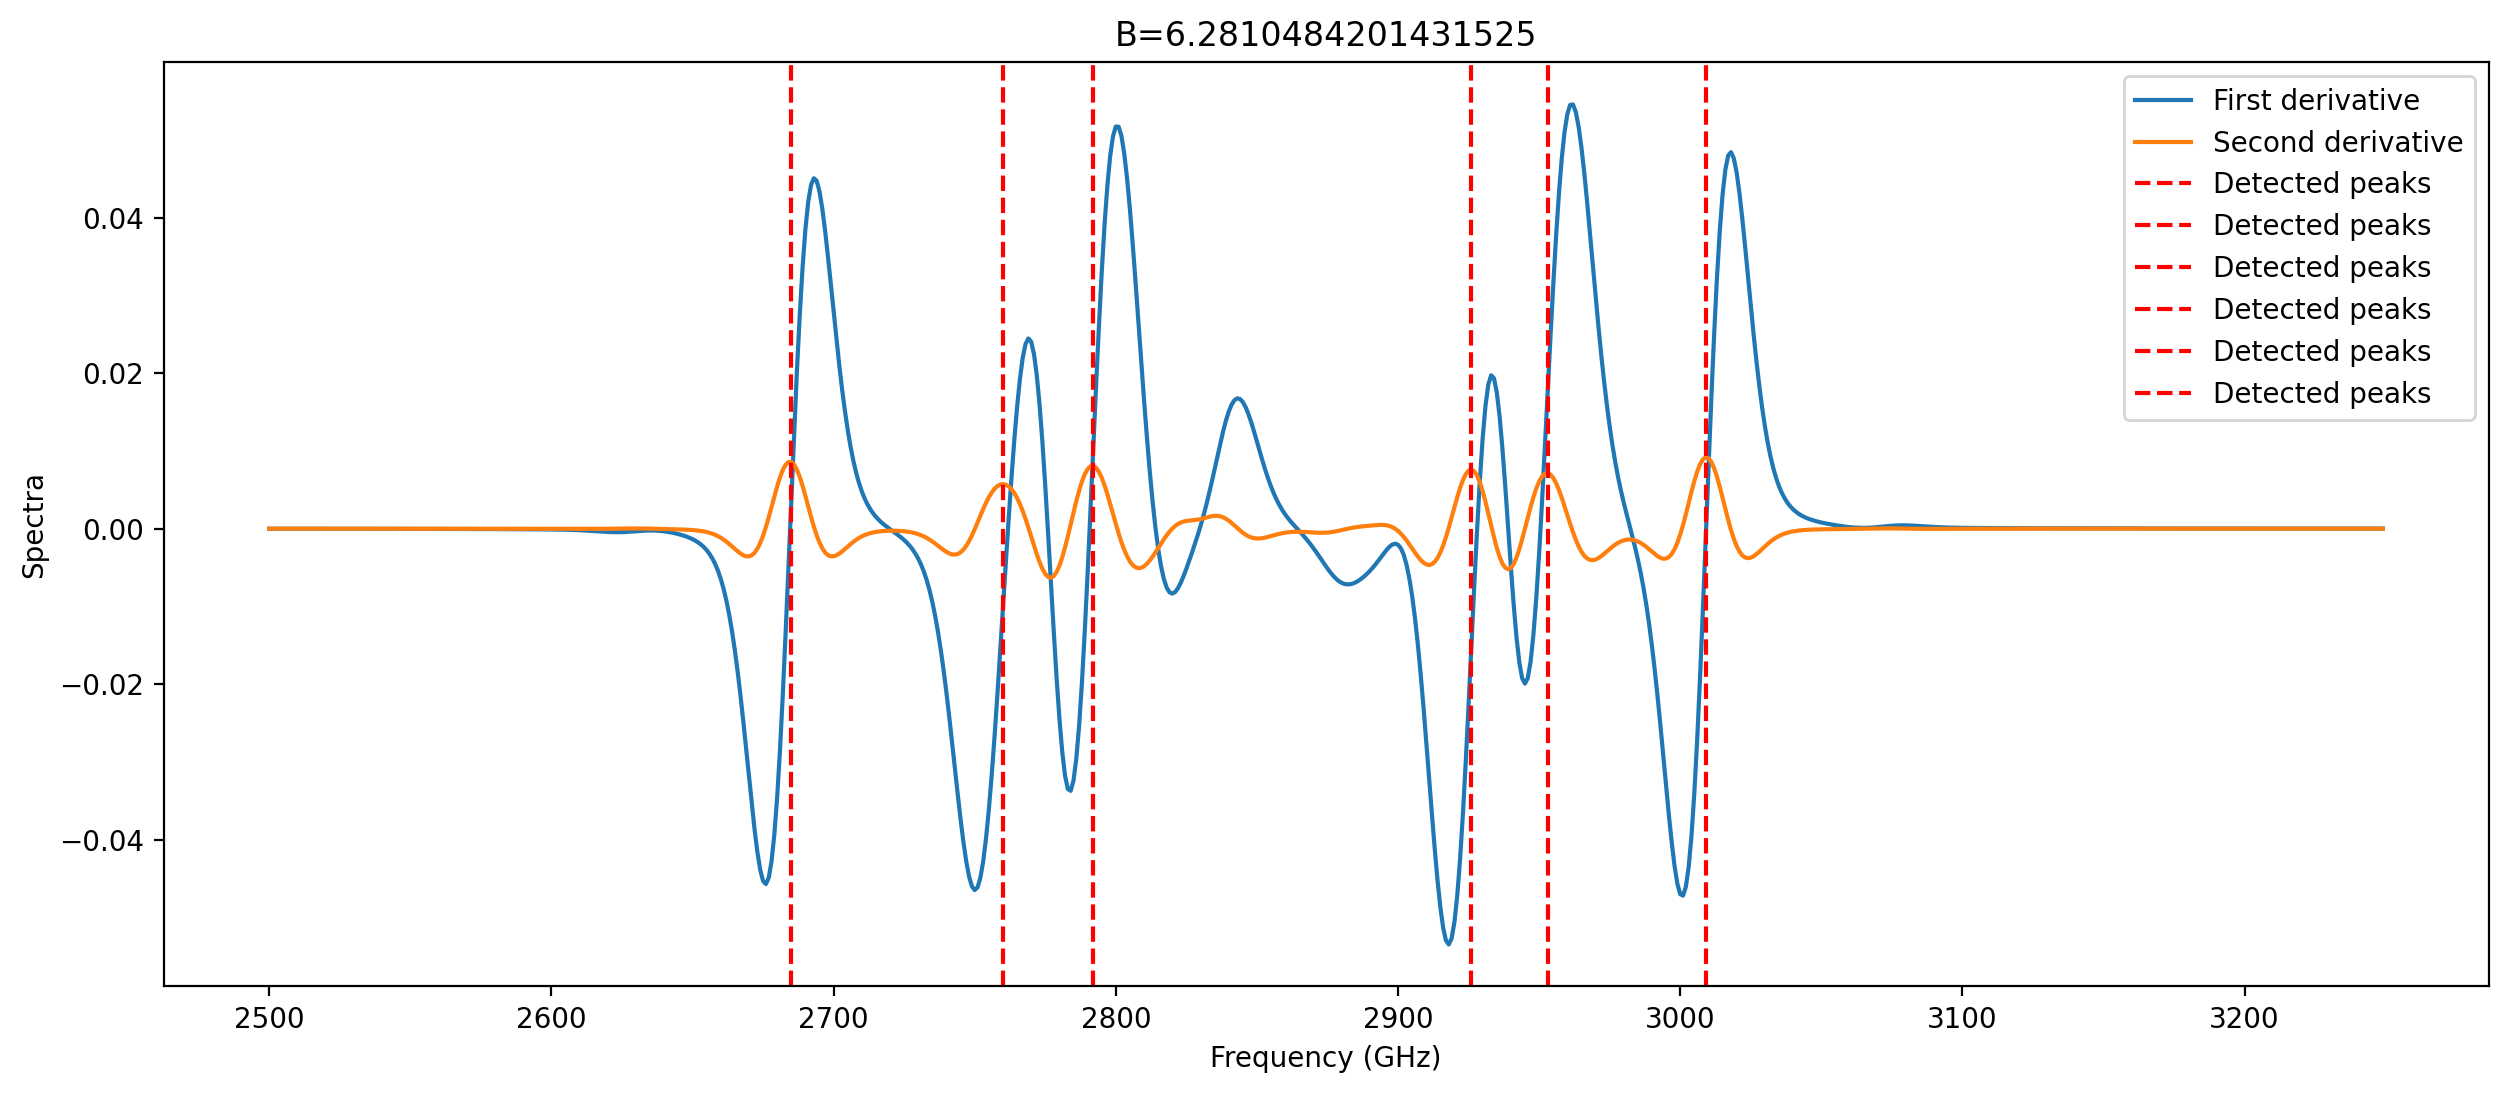

In [27]:
plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, ds_dx[k], label='First derivative')
plt.plot(x_axis, d2s_dx2[k], label='Second derivative')
for pos in posizioni_totali[k]:
    plt.axvline(x=pos, color='red', linestyle='--', label='Detected peaks')
plt.title(f"B={B[k]}")
plt.xlabel('Frequency (GHz)')
plt.ylabel('Spectra')
plt.legend()
plt.show()

In [28]:
from ml_odmr.otto_voigt import fit_otto_pseudo_voigt, otto_pseudo_voigt

ampiezze_fit, posizioni_fit, gamma_fit, sigma_fit, eta_fit, y0_fit = fit_otto_pseudo_voigt(
    f,
    s[k],
    info_totale[k]['peak_heights']*10,
    posizioni_totali[k],
    info_totale[k]['widths']*2,
    info_totale[k]['widths'],  # Stima iniziale per sigma (gaussiana) come metà di gamma (lorentziana)
    np.full_like(info_totale[k]['widths'], 0.5)  # Stima iniziale per eta (mix tra gaussiana e lorentziana) a 0.5
)

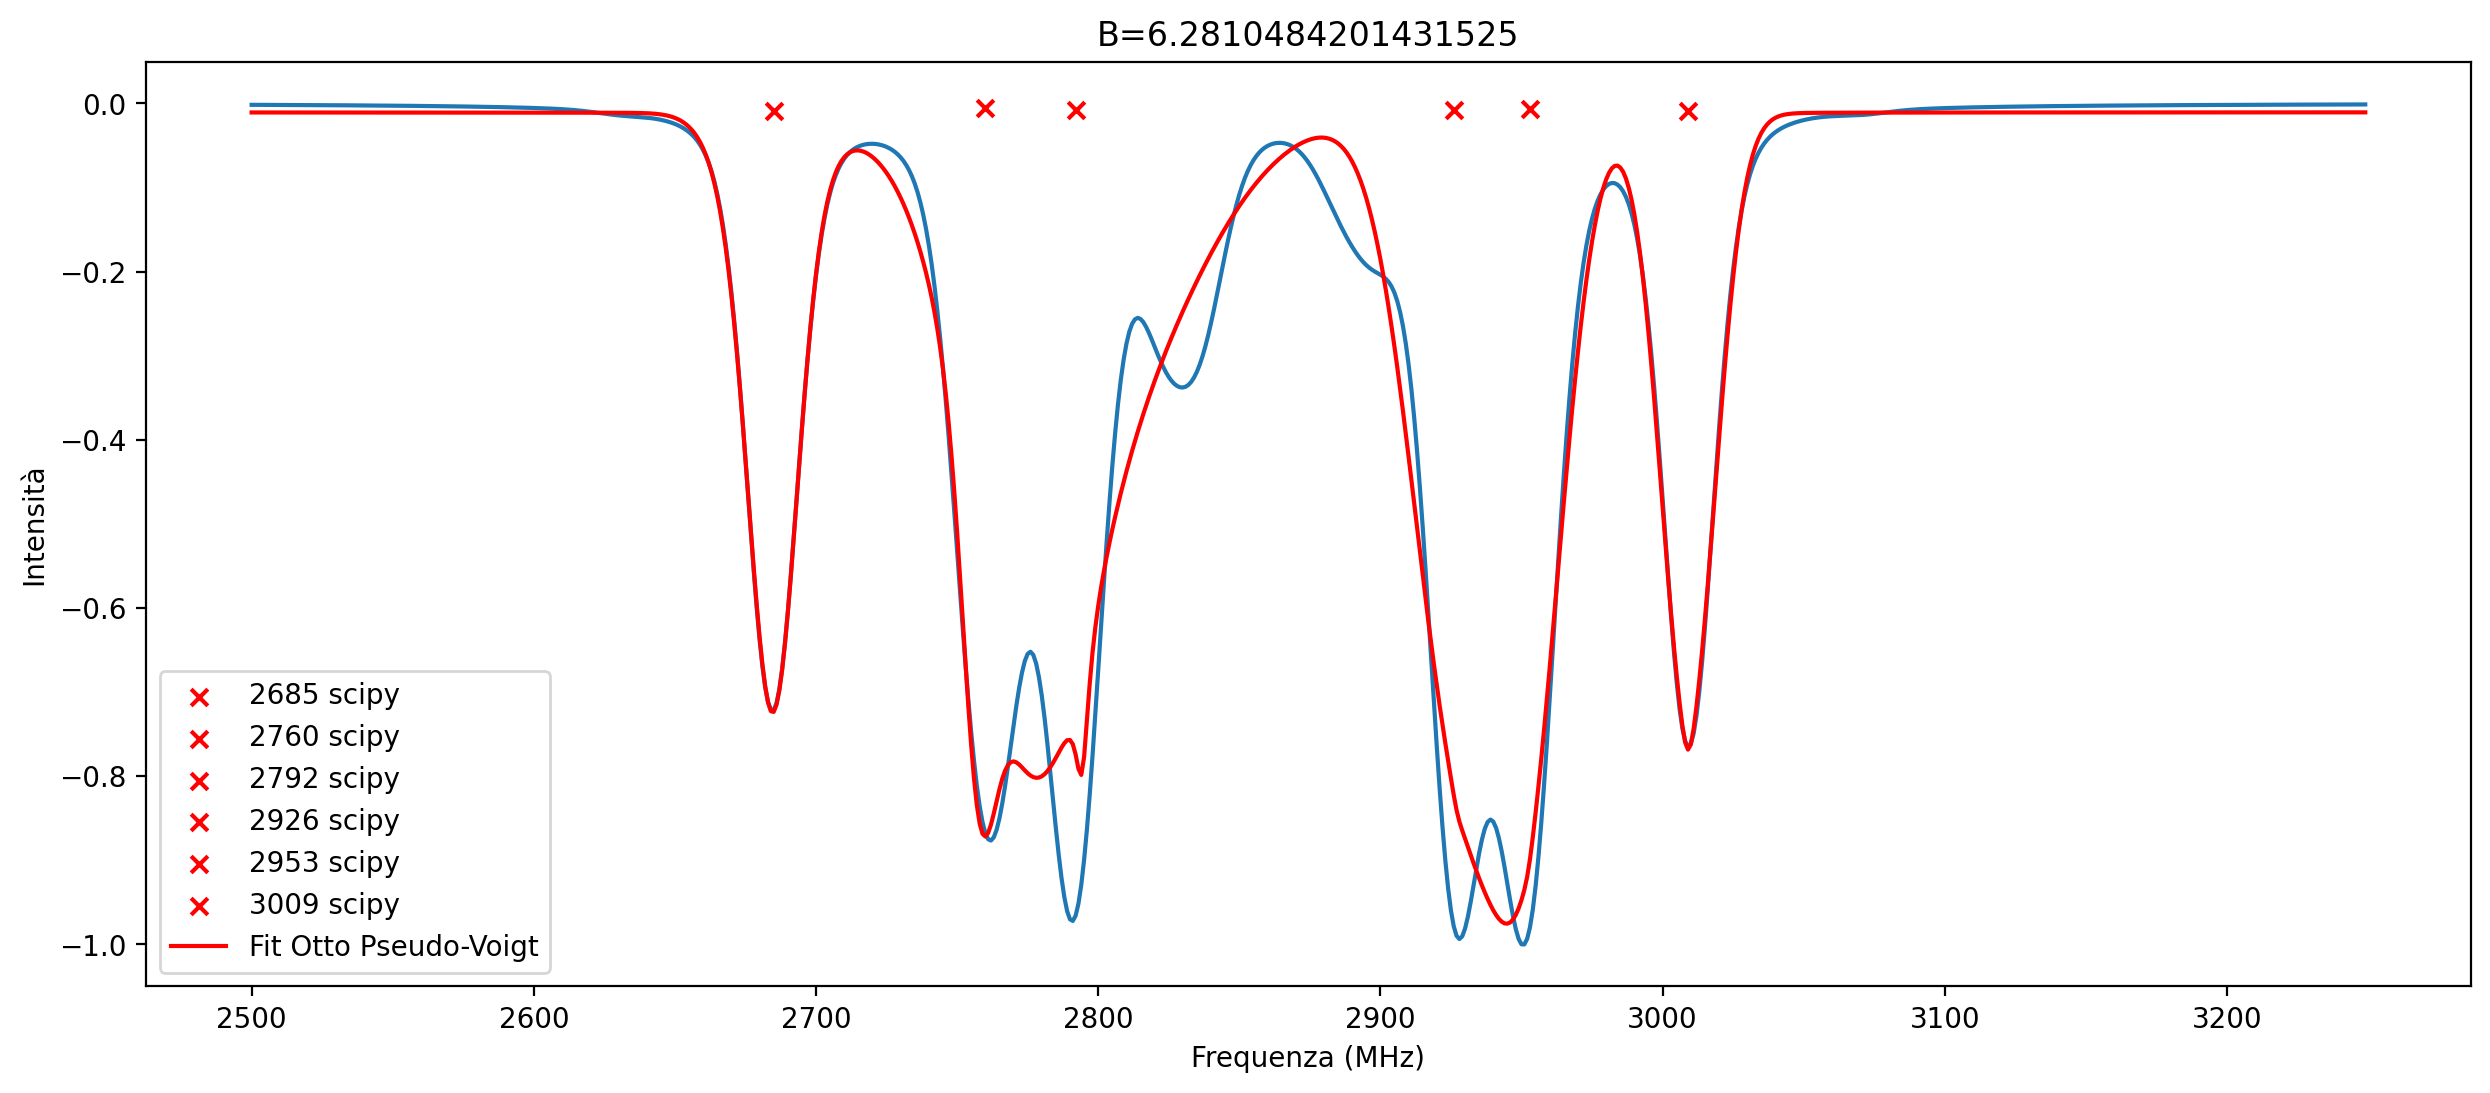

In [29]:
plt.figure(figsize=(15, 6), dpi=200)
plt.plot(x_axis, s[k])
for pos in posizioni_totali[k]:
    h = info_totale[k]['peak_heights'][np.where(posizioni_totali[k] == pos)[0][0]]
    plt.scatter(pos, -h, color='red', marker='x', label=f'{pos} scipy')  # Evidenziamo i picchi
plt.plot(f, -otto_pseudo_voigt(f, ampiezze_fit, posizioni_fit, gamma_fit, sigma_fit, eta_fit, y0_fit), color='red', label='Fit Otto Pseudo-Voigt')  # Plot del fit
plt.title(f"B={B[k]}")
plt.xlabel('Frequenza (MHz)')
plt.ylabel('Intensità')
plt.legend()
plt.show()

In [30]:
posizioni_fit

array([2684.76796783, 2757.58543021, 2794.2837121 , 2927.21729015,
       2952.43250377, 3009.08915514, 2683.77414286, 2774.5       ])